# 🔍 Analyse post-entraînement du modèle DistilBERT

Ce notebook vise à :
1. **Analyser les erreurs** du modèle sur le jeu de test.
2. **Explorer la calibration** des prédictions.
3. **Étudier l'effet du seuil de décision** (au lieu de 0.5) pour améliorer les performances selon le contexte d'usage.

Les données de test sont disponibles dans `notebooks/data/test.csv`.


In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay, precision_recall_curve, f1_score, accuracy_score, precision_score, recall_score
)
from sklearn.calibration import calibration_curve

import tensorflow as tf
from transformers import DistilBertTokenizerFast, TFAutoModel
from tensorflow_addons.metrics import F1Score
from IPython.display import display

# Ajout du chemin racine du projet pour permettre les imports de modules locaux
project_root = Path.cwd().parent  # ex: /home/user/lucen-ia/
sys.path.insert(0, str(project_root))

from lucenai.training.model import load_best_model_and_tokenizer
from lucenai.config.settings import TRAINING_PARAMS, MODEL_PATHS


2025-07-07 08:38:17.703900: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-07 08:38:17.706654: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-07 08:38:17.760303: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-07 08:38:17.761563: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-07 08:38:18.710231: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

## 📦 Chargement du modèle et du tokenizer

In [2]:
model_path = MODEL_PATHS.best_model
tokenizer_path = MODEL_PATHS.tokenizer

model, tokenizer = load_best_model_and_tokenizer(model_path, tokenizer_path)


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


📥 Loading tokenizer from: /teamspace/studios/this_studio/lucen-ia/lucenai/models/distilbert_sentiment/tokenizer
✅ Tokenizer loaded successfully.
🧠 Rebuilding model architecture...


2025-07-07 08:38:21.431469: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.weight', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TF

🏗️ Building deep architecture...
   ✅ Input layers created
   ✅ DistilBERT integrated
   ✅ [CLS] token extracted
   ✅ Deep classification head added

✅ Model successfully built!
📦 Loading model weights from: /teamspace/studios/this_studio/lucen-ia/lucenai/models/distilbert_sentiment/checkpoint/best_model


2025-07-07 08:38:26.887659: W tensorflow/core/util/tensor_slice_reader.cc:97] Could not open /teamspace/studios/this_studio/lucen-ia/lucenai/models/distilbert_sentiment/checkpoint/best_model: FAILED_PRECONDITION: /teamspace/studios/this_studio/lucen-ia/lucenai/models/distilbert_sentiment/checkpoint/best_model; Is a directory: perhaps your file is in a different file format and you need to use a different restore operator?


✅ Weights loaded successfully.


## 📄 Chargement des données de test

In [11]:
try:
    df_test = pd.read_csv("./data/test.csv")
    print(f"✅ Fichier chargé avec succès, Nombre d'échantillons : {len(df_test)}")
    display(df_test.head(10))
except FileNotFoundError:
    print("❌ Erreur : le fichier spécifié est introuvable.")
except pd.errors.EmptyDataError:
    print("❌ Erreur : le fichier est vide.")
except pd.errors.ParserError:
    print("❌ Erreur : échec de l'analyse du fichier.")
except Exception as e:
    print(f"❌ Une erreur inattendue est survenue : {e}")

✅ Fichier chargé avec succès, Nombre d'échantillons : 857


,id,full_text,clean_text,label
0,1868,"RT @fundstrat: FYI, I respect those who do tec...",fyi i respect those who do technical analysis ...,1
1,4834,"RT @stephanlivera: To understand bitcoin, you ...",to understand bitcoin you must first understan...,0
2,4501,RT @HackRead: Teen hacks Ledger hardware crypt...,teen hacks ledger hardware cryptocurrency wall...,1
3,697,@Trader_Dante Am only interested in your 24k g...,am only interested in your 24k gold bitcoin to...,1
4,3506,New post (Drive Genuine Cryptocurrency bitcoin...,new post drive genuine cryptocurrency bitcoin ...,1
5,4642,HASHING24 via /r/BitcoinMarkets https://t.co/j...,hashing24 via rbitcoinmarkets free at,1
6,1378,"New post: ""College students are using student ...",new post college students are using student lo...,1
7,716,Pullback Ahead? Bitcoin Hits Stiff Resistance ...,pullback ahead bitcoin hits stiff resistance a...,0
8,563,You can simply stake your XP coin without wall...,you can simply stake your xp coin without wall...,1
9,3099,RT @mexc_life: STAGE TWO: ENDING SOON !!!\n\n...,stage two ending soon 1 day to go with eth is ...,1


## ✏️ Préparation des données pour le modèle

In [4]:
X_test = tokenizer(
    df_test["clean_text"].tolist(),
    truncation=True,
    padding="max_length",
    max_length=TRAINING_PARAMS.max_len,
    return_tensors="tf"
)

# Cibles réelles
y_true = df_test["label"].values
# Prédictions de probabilité du modèle
y_pred_proba = model.predict(dict(X_test)).squeeze()


27/27 [==============================] - 15s 493ms/step


## ❌ Analyse des erreurs de prédiction

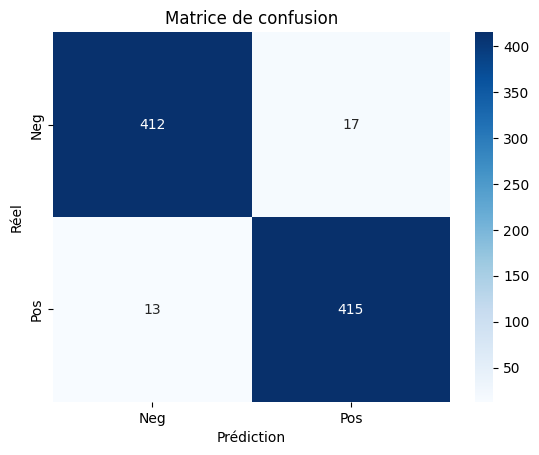

              precision    recall  f1-score   support

           0       0.97      0.96      0.96       429
           1       0.96      0.97      0.97       428

    accuracy                           0.96       857
   macro avg       0.97      0.96      0.96       857
weighted avg       0.97      0.96      0.96       857



In [5]:
y_pred = (y_pred_proba >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"])
plt.title("Matrice de confusion")
plt.xlabel("Prédiction")
plt.ylabel("Réel")
plt.show()

print(classification_report(y_true, y_pred))

## 🔍 Analyse des erreurs : Faux positifs et faux négatifs

In [7]:
from IPython.display import display, HTML

def display_errors_with_full_text(df: pd.DataFrame, title: str, n: int = 5):
    """Affiche une vue enrichie des erreurs avec clean_text, full_text et probabilité."""
    rows = []
    for _, row in df.head(n).iterrows():
        html_row = f"""
        <div style="margin-bottom: 1.5em; padding: 0.5em; border-bottom: 1px solid #ddd;">
            <div><strong>🧹 Clean:</strong> {row['clean_text']}</div>
            <div style="color: #555;"><strong>🗒️ Original:</strong> {row['full_text']}</div>
            <div style="text-align: right;"><strong>🔢 Proba:</strong> {row['prob']:.4f}</div>
        </div>
        """
        rows.append(html_row)

    display(HTML(f"<h4>{title}</h4>" + "".join(rows)))

# Calcul des prédictions binaires
y_pred = (y_pred_proba > 0.5).astype(int)

# Création d’un DataFrame pour visualiser les erreurs
df_errors = df_test.copy()
df_errors["y_true"] = y_true
df_errors["y_pred"] = y_pred
df_errors["prob"] = y_pred_proba

# Afficher les faux positifs
false_positives = df_errors[(df_errors["y_true"] == 0) & (df_errors["y_pred"] == 1)]
display_errors_with_full_text(false_positives, "🔴 Faux positifs", n=5)

# Afficher les faux négatifs
false_negatives = df_errors[(df_errors["y_true"] == 1) & (df_errors["y_pred"] == 0)]
display_errors_with_full_text(false_negatives, "🔵 Faux négatifs", n=5)

## 🎛️ Calibration des probabilités
La calibration permet de vérifier si les probabilités prédites par le modèle correspondent bien à la réalité observée.
Dans le graphique ci-dessous :
- La courbe en pointillés représente une calibration parfaite : les probabilités prédites sont parfaitement alignées avec la réalité.
- La courbe bleue montre la calibration réelle du modèle.
    - Si elle est au-dessus de la diagonale, le modèle est sous-confiant (il prédit trop bas).
    - Si elle est en dessous, il est trop confiant (il surestime les prédictions).

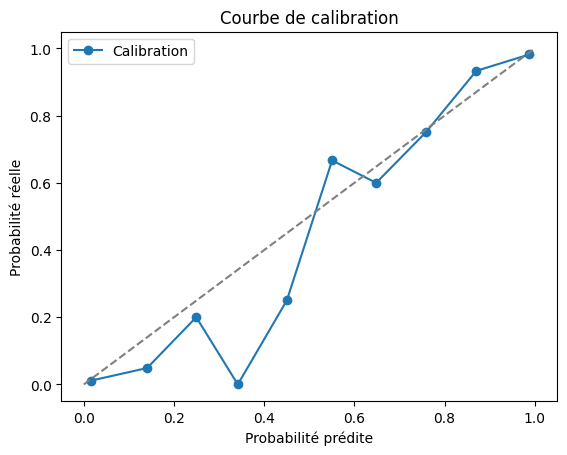

In [8]:
prob_true, prob_pred = calibration_curve(y_true, y_pred_proba, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o', label='Calibration')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("Courbe de calibration")
plt.xlabel("Probabilité prédite")
plt.ylabel("Probabilité réelle")
plt.legend()
plt.show()

## 🧮 Étude du seuil de décision optimal
Dans cette section, nous explorons l’impact du seuil de décision sur la performance du modèle, en traçant l’évolution du F1-score pour différents seuils compris entre 0 et 1.
Le seuil optimal correspond à celui qui maximise le F1-score.

🎯 Seuil optimal F1: 0.51 (F1 = 0.9662)


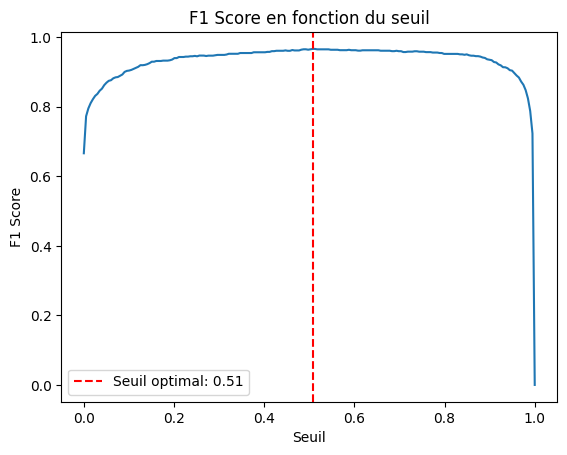

In [9]:
thresholds = np.linspace(0, 1, 200)
f1s = [f1_score(y_true, y_pred_proba >= t) for t in thresholds]

best_t = thresholds[np.argmax(f1s)]
print(f"🎯 Seuil optimal F1: {best_t:.2f} (F1 = {max(f1s):.4f})")

plt.plot(thresholds, f1s)
plt.axvline(best_t, color='r', linestyle='--', label=f'Seuil optimal: {best_t:.2f}')
plt.title("F1 Score en fonction du seuil")
plt.xlabel("Seuil")
plt.ylabel("F1 Score")
plt.legend()
plt.show()


## 📊 Comparaison des matrices de confusion (0.5 vs seuil optimal)

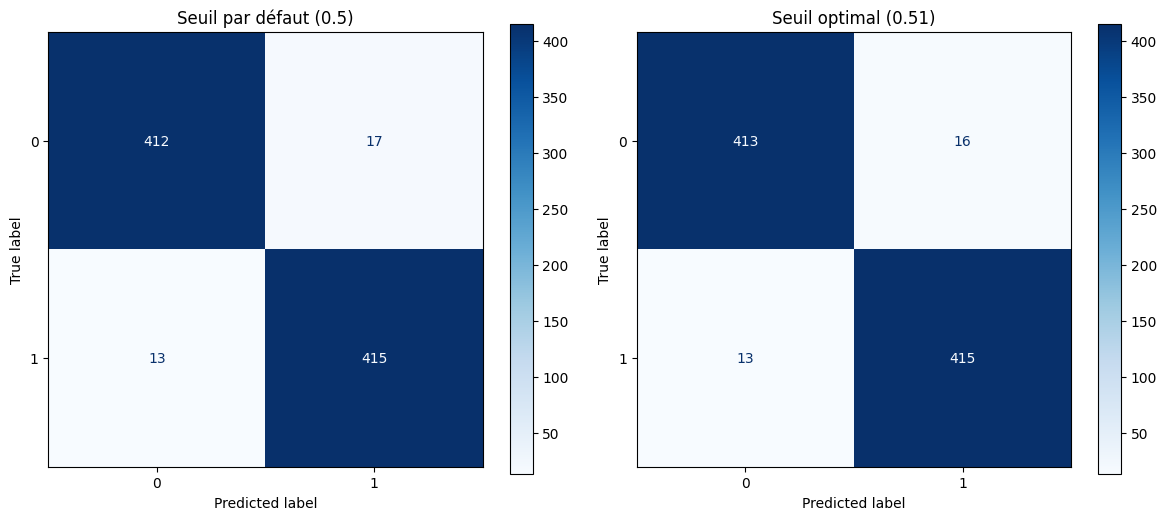

In [10]:
# Prédictions au seuil par défaut
y_pred_default = (y_pred_proba >= 0.5).astype(int)
cm_default = confusion_matrix(y_true, y_pred_default)

# Prédictions au seuil optimal
y_pred_opt = (y_pred_proba >= best_t).astype(int)
cm_opt = confusion_matrix(y_true, y_pred_opt)

# Affichage côte à côte
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matrice par défaut
ConfusionMatrixDisplay(cm_default).plot(ax=axes[0], cmap="Blues", values_format='d')
axes[0].set_title("Seuil par défaut (0.5)")

# Matrice seuil optimal
ConfusionMatrixDisplay(cm_opt).plot(ax=axes[1], cmap="Blues", values_format='d')
axes[1].set_title(f"Seuil optimal ({best_t:.2f})")

plt.tight_layout()
plt.show()

## ✅ Conclusion
Le modèle fine-tuné basé sur DistilBERT répond pleinement aux besoins de classification de sentiments sur les tweets liés aux crypto-monnaies.

Les performances sont solides et cohérentes sur les deux classes:
| Classe        | Précision | Rappel | F1-score | Support |
|---------------|-----------|--------|----------|---------|
| 0 (négatif)   | 0.97      | 0.96   | 0.96     | 429     |
| 1 (positif)   | 0.96      | 0.97   | 0.97     | 428     |
| **Accuracy**  |           |        | **0.96** | **857** |
| Macro avg     | 0.97      | 0.96   | 0.96     | 857     |
| Weighted avg  | 0.97      | 0.96   | 0.96     | 857     |

L'ajustement du seuil de décision a été exploré. Bien qu’un seuil optimal (≈0.51) ait été identifié, le gain observé est marginal. La valeur par défaut de 0.5 reste donc tout à fait pertinente dans ce contexte.

👉 Le modèle est fiable, bien calibré, et adapté pour une mise en production ou un déploiement en API.